# NJ Municipality Data Pipeline – Exploration Notebook

**Purpose:** Explore all loaded data, check row counts, preview tables,
and run quality-of-life / real estate analyses.

### Quick Start
1. Run all pipelines first:  
   `python -m pipeline.run_all`  
   or start fast with no API keys:  
   `python -m pipeline.run_all --only zillow fema_flood cdc_places nj_green nj_dca`
2. Then run this notebook cell by cell.

In [1]:
import sys
sys.path.insert(0, '..')  # add project root

import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

from config import DB_PATH

conn = duckdb.connect(DB_PATH, read_only=False)
print(f'Connected to: {DB_PATH}')
print(f'DuckDB version: {duckdb.__version__}')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

Connected to: /Users/caiotormin/torm/nj_pipeline/notebooks/../data/db/nj_pipeline.duckdb
DuckDB version: 1.4.3


## 1. Data Inventory

In [2]:
tables = conn.execute("""
    SELECT table_name, table_type
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_type, table_name
""").df()

rows = []
for _, row in tables.iterrows():
    try:
        cnt = conn.execute(f"SELECT COUNT(*) FROM {row['table_name']}").fetchone()[0]
    except:
        cnt = -1
    rows.append({'table': row['table_name'], 'type': row['table_type'], 'rows': cnt})

inv = pd.DataFrame(rows)
inv['rows'] = inv['rows'].map(lambda x: f'{x:,}' if x >= 0 else 'N/A')
print(inv.to_string(index=False))

                table       type    rows
           cdc_places BASE TABLE  12,914
      cdc_places_wide BASE TABLE   1,174
      cdc_places_zcta BASE TABLE  12,914
           census_acs BASE TABLE  14,311
  fema_nfip_claims_nj BASE TABLE   2,193
fema_nfip_policies_nj BASE TABLE     630
      hud_chas_places BASE TABLE       4
    hud_fair_mkt_rent BASE TABLE      11
            hud_safmr BASE TABLE      21
      nj_equalization BASE TABLE  13,565
      nj_property_tax BASE TABLE  15,849
   zillow_home_values BASE TABLE 683,279
          zillow_rent BASE TABLE  30,590
   fema_flood_summary       VIEW     630
        zillow_latest       VIEW     547


## 2. Zillow – Home Values & Rent

In [3]:
try:
    latest = conn.execute('SELECT * FROM zillow_latest ORDER BY zhvi_current DESC').df()
    print(f'Zip codes with Zillow data: {len(latest):,}')
    print(latest[['zip_code','city','county','zhvi_current','zori_current',
                   'price_to_rent_ratio','zhvi_yoy_pct','zhvi_5yr_pct']].head(20).to_string(index=False))
except Exception as e:
    print(f'Zillow not loaded yet: {e}')

Zip codes with Zillow data: 547
zip_code                city          county  zhvi_current  zori_current  price_to_rent_ratio  zhvi_yoy_pct  zhvi_5yr_pct
   07723                Deal Monmouth County  4.162224e+06           NaN                  NaN          9.91         84.34
   07620              Alpine   Bergen County  2.955123e+06           NaN                  NaN         10.30         48.11
   08202              Avalon Cape May County  2.637361e+06           NaN                  NaN         -0.51         38.46
   08247        Stone Harbor Cape May County  2.477278e+06           NaN                  NaN          4.84         47.81
   07711          Allenhurst Monmouth County  2.353570e+06           NaN                  NaN          6.43         93.38
   08750            Sea Girt Monmouth County  2.308441e+06           NaN                  NaN          9.87         71.48
   07078         Short Hills    Essex County  2.250487e+06        5617.5                 33.4          6.01       

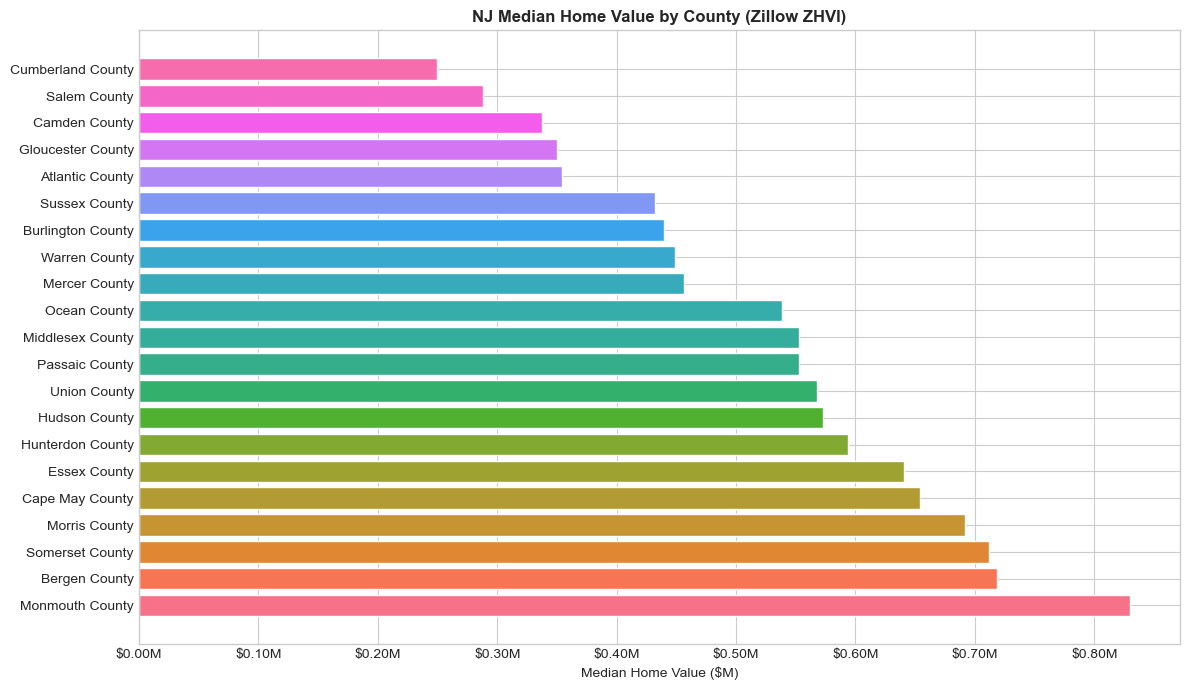

In [4]:
try:
    county_zhvi = conn.execute("""
        SELECT county,
               MEDIAN(zhvi_current) AS median_home_value,
               COUNT(*) AS zip_count
        FROM zillow_latest
        WHERE county IS NOT NULL
        GROUP BY county
        ORDER BY median_home_value DESC
    """).df()

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(county_zhvi['county'], county_zhvi['median_home_value'] / 1e6,
            color=sns.color_palette('husl', len(county_zhvi)))
    ax.set_xlabel('Median Home Value ($M)')
    ax.set_title('NJ Median Home Value by County (Zillow ZHVI)', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f}M'))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Could not plot: {e}')

In [2]:
# Price-to-rent ratio distribution
try:
    ptr = conn.execute("""
        SELECT zip_code, city, county, price_to_rent_ratio
        FROM zillow_latest
        WHERE price_to_rent_ratio BETWEEN 5 AND 60
        ORDER BY price_to_rent_ratio
    """).df()

    fig = px.histogram(ptr, x='price_to_rent_ratio',
                       color='county', nbins=40,
                       title='Price-to-Rent Ratio Distribution by County (NJ)',
                       labels={'price_to_rent_ratio': 'Price-to-Rent Ratio'},
                       template='plotly_white', height=450)
    fig.add_vline(x=15, line_dash='dash', annotation_text='15x = rent favored')
    fig.add_vline(x=20, line_dash='dash', line_color='red', annotation_text='20x = neutral')
    fig.show()
    print('\nRule of thumb: <15 = buying favored | 15-20 = neutral | >20 = renting favored')
except Exception as e:
    print(f'Could not plot: {e}')

Could not plot: name 'conn' is not defined


## 3. Census ACS – Demographics & Economics

In [6]:
try:
    acs = conn.execute("""
        SELECT *
        FROM acs_places
        WHERE acs_year = (SELECT MAX(acs_year) FROM acs_places)
          AND pop_total > 1000
        ORDER BY income_median_hh DESC NULLS LAST
    """).df()

    print(f'Municipalities (pop > 1000): {len(acs)}')
    cols = ['NAME','pop_total','income_median_hh','poverty_rate',
            'unemployment_rate_acs','homeownership_rate',
            'home_value_median','pct_bachelors_plus','avg_commute_minutes']
    print(acs[cols].head(20).to_string(index=False))
except Exception as e:
    print(f'ACS data not loaded yet: {e}\nRun: python -m pipeline.run_all --only census_acs')

ACS data not loaded yet: Catalog Error: Table with name acs_places does not exist!
Did you mean "cdc_places"?

LINE 3:         FROM acs_places
                     ^
Run: python -m pipeline.run_all --only census_acs


In [7]:
# Income vs Home Value – bubble chart
try:
    fig = px.scatter(
        acs.dropna(subset=['income_median_hh','home_value_median']),
        x='income_median_hh',
        y='home_value_median',
        size='pop_total',
        color='pct_bachelors_plus',
        hover_name='NAME',
        hover_data=['poverty_rate','unemployment_rate_acs','homeownership_rate'],
        title='Median Income vs. Home Value – NJ Municipalities (ACS)',
        labels={'income_median_hh': 'Median HH Income ($)',
                'home_value_median': 'Median Home Value ($)',
                'pct_bachelors_plus': "% Bachelor's+"},
        color_continuous_scale='Viridis',
        template='plotly_white', height=550
    )
    fig.update_layout(xaxis_tickformat='$,.0f', yaxis_tickformat='$,.0f')
    fig.show()
except Exception as e:
    print(f'Could not plot: {e}')

Could not plot: name 'acs' is not defined


## 4. Affordability Index

In [8]:
try:
    afford = conn.execute("""
        SELECT * FROM v_affordability_index
        WHERE home_price_to_income_ratio IS NOT NULL
        ORDER BY home_price_to_income_ratio
    """).df()

    print('MOST AFFORDABLE (lowest price/income ratio):')
    print(afford[['zip_code','city','home_value_zillow','income_median_hh',
                   'home_price_to_income_ratio','rent_to_income_pct',
                   'property_tax_rate','est_annual_ownership_cost_usd']].head(15).to_string(index=False))
    print()
    print('LEAST AFFORDABLE:')
    print(afford[['zip_code','city','home_value_zillow','income_median_hh',
                   'home_price_to_income_ratio','rent_to_income_pct']].tail(10).to_string(index=False))
except Exception as e:
    print(f'Affordability view not available yet: {e}\nRun the full pipeline first.')

Affordability view not available yet: Catalog Error: Table with name v_affordability_index does not exist!
Did you mean "duckdb_indexes"?

LINE 2:         SELECT * FROM v_affordability_index
                              ^
Run the full pipeline first.


In [9]:
# Affordability vs. Appreciation – quadrant chart
try:
    fig = px.scatter(
        afford.dropna(subset=['home_price_to_income_ratio','home_value_yoy_pct']),
        x='home_price_to_income_ratio',
        y='home_value_yoy_pct',
        size='home_value_zillow',
        color='rent_to_income_pct',
        hover_name='city',
        hover_data=['zip_code','home_value_zillow','property_tax_rate'],
        title='NJ Zip Codes: Affordability vs. YoY Appreciation',
        labels={'home_price_to_income_ratio': 'Price/Income Ratio (lower = affordable)',
                'home_value_yoy_pct': 'YoY Appreciation (%)',
                'rent_to_income_pct': 'Rent/Income %'},
        color_continuous_scale='RdYlGn_r',
        template='plotly_white', height=550
    )
    med_ptr = afford['home_price_to_income_ratio'].median()
    fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.4)
    fig.add_vline(x=med_ptr, line_dash='dash', line_color='gray', opacity=0.4,
                  annotation_text='Median')
    fig.show()
    print('\nTop-right quadrant: Appreciating AND affordable = best buyer opportunities')
except Exception as e:
    print(f'Could not plot: {e}')

Could not plot: name 'afford' is not defined


## 5. Health Metrics (CDC PLACES)

In [10]:
try:
    health = conn.execute("""
        SELECT * FROM cdc_places_wide
        WHERE year = (SELECT MAX(year) FROM cdc_places_wide)
        ORDER BY zcta
    """).df()

    print(f'Health data: {len(health)} ZCTAs')
    health_cols = [c for c in ['diabetes','obesity','csmoking','depression','lpa',
                               'access2','chd','mhlth','sleep','bphigh'] if c in health.columns]
    if health_cols:
        medians = health[health_cols].median().sort_values(ascending=False)
        print('\nMedian prevalence across NJ ZCTAs (%):')
        for col, val in medians.items():
            bar = '=' * int(val / 2)
            print(f'  {col:<20} {val:5.1f}%  {bar}')
except Exception as e:
    print(f'Health data not loaded: {e}\nRun: python -m pipeline.run_all --only cdc_places')

Health data: 587 ZCTAs

Median prevalence across NJ ZCTAs (%):
  bphigh                32.3%  ================
  obesity               28.2%  ==============
  lpa                   22.0%  ===========
  depression            15.8%  =======
  mhlth                 14.5%  =======
  csmoking              10.3%  =====
  diabetes               9.8%  ====
  access2                8.1%  ====
  chd                    5.5%  ==
Health data not loaded: cannot convert float NaN to integer
Run: python -m pipeline.run_all --only cdc_places


## 6. Tree Canopy & Green Space

In [11]:
try:
    canopy = conn.execute('SELECT * FROM nj_canopy_by_county ORDER BY avg_tree_canopy_pct DESC').df()
    print('Tree canopy by county:')
    print(canopy.to_string(index=False))

    if not canopy.empty and 'avg_tree_canopy_pct' in canopy.columns:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(canopy['county_fips'], canopy['avg_tree_canopy_pct'],
                color=sns.color_palette('Greens_r', len(canopy)))
        ax.set_xlabel('Avg Tree Canopy Cover (%)')
        ax.set_title('NJ Tree Canopy Coverage by County', fontweight='bold')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f'Tree canopy not loaded: {e}\nRun: python -m pipeline.run_all --only nj_green')

Tree canopy not loaded: Catalog Error: Table with name nj_canopy_by_county does not exist!
Did you mean "pg_constraint"?

LINE 1: SELECT * FROM nj_canopy_by_county ORDER BY avg_tree_canopy_pct DESC
                      ^
Run: python -m pipeline.run_all --only nj_green


## 7. Flood Risk (FEMA NFIP)

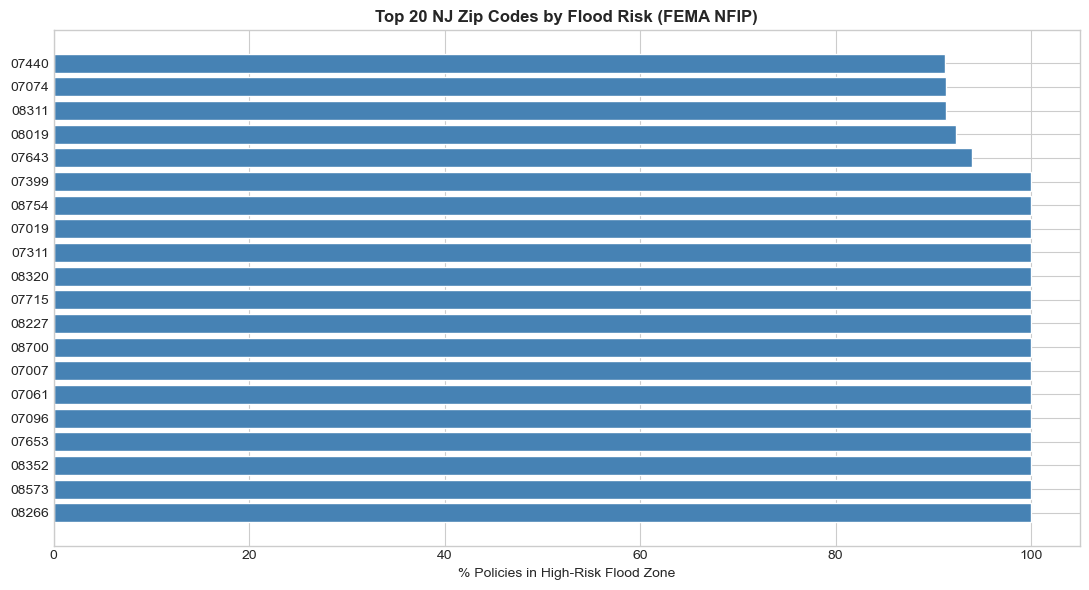

In [12]:
try:
    flood = conn.execute("""
        SELECT zip_code, policy_count, pct_high_risk_flood_zone,
               total_claims_all_time_usd, total_claim_count
        FROM fema_flood_summary
        ORDER BY pct_high_risk_flood_zone DESC NULLS LAST
    """).df()

    print(f'Flood risk: {len(flood)} zip codes')
    print(flood.head(20).to_string(index=False))

    # Bar chart of top 20 highest-risk zips
    top20 = flood.dropna(subset=['pct_high_risk_flood_zone']).head(20)
    if not top20.empty:
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.barh(top20['zip_code'].astype(str), top20['pct_high_risk_flood_zone'],
                color='steelblue')
        ax.set_xlabel('% Policies in High-Risk Flood Zone')
        ax.set_title('Top 20 NJ Zip Codes by Flood Risk (FEMA NFIP)', fontweight='bold')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f'Flood data not loaded: {e}\nRun: python -m pipeline.run_all --only fema_flood')

## 8. Composite Quality-of-Life Score

In [1]:
# Build a composite QoL score from available metrics
try:
    scorecard = conn.execute('SELECT * FROM v_zipcode_scorecard').df()
    print(f'Scorecard zip codes: {len(scorecard)}')

    # Optionally add affordability ratios
    try:
        afford_small = conn.execute("""
            SELECT zip_code, home_price_to_income_ratio
            FROM v_affordability_index
        """).df()
        scorecard = scorecard.merge(afford_small, on='zip_code', how='left')
    except:
        pass

    # Metrics: (column_name, direction)  +1 = higher is better, -1 = lower is better
    score_metrics = [
        ('income_median_hh',           +1),
        ('home_price_to_income_ratio',  -1),
        ('poverty_rate',                -1),
        ('unemployment_rate_acs',       -1),
        ('pct_bachelors_plus',          +1),
        ('rent_burden_30plus_pct',      -1),
        ('avg_tree_canopy_pct',         +1),
        ('uninsured_pct',               -1),
        ('pct_high_risk_flood_zone',    -1),
        ('physical_inactivity_pct',     -1),
        ('avg_commute_minutes',         -1),
        ('pct_wfh',                    +1),
    ]

    sc = scorecard.copy()
    parts = []
    for col, direction in score_metrics:
        if col not in sc.columns:
            continue
        v = pd.to_numeric(sc[col], errors='coerce')
        normed = (v - v.min()) / (v.max() - v.min() + 1e-9)
        if direction == -1:
            normed = 1 - normed
        parts.append(normed)

    if parts:
        sc['qol_score'] = (pd.concat(parts, axis=1).mean(axis=1) * 100).round(1)
        top20 = sc.nlargest(20, 'qol_score')[['zip_code','city','county','qol_score',
                                               'income_median_hh','home_price_to_income_ratio',
                                               'poverty_rate','avg_tree_canopy_pct',
                                               'pct_high_risk_flood_zone']]
        print('\nTop 20 Quality-of-Life Zip Codes:')
        print(top20.to_string(index=False))

        fig = px.bar(top20.sort_values('qol_score'),
                     x='qol_score', y='zip_code', orientation='h',
                     color='income_median_hh', hover_data=['city','county'],
                     title='Top 20 NJ Zip Codes by Composite Quality-of-Life Score',
                     labels={'qol_score': 'QoL Score (0-100)',
                             'income_median_hh': 'Median HH Income'},
                     color_continuous_scale='Viridis', template='plotly_white', height=550)
        fig.show()
except Exception as e:
    print(f'Run the full pipeline first.\n{e}')

Run the full pipeline first.
name 'conn' is not defined


## 9. Reference: Pipeline Commands & API Keys

### Run pipelines (from project root)
```bash
# No API keys needed (start here)
python -m pipeline.run_all --only zillow fema_flood cdc_places nj_green nj_dca

# Add Census data (requires CENSUS_API_KEY in .env)
python -m pipeline.run_all --only census_acs

# Full run
python -m pipeline.run_all

# Force re-download everything
python -m pipeline.run_all --force

# List all pipelines
python -m pipeline.run_all --list
```

### Free API Keys Required
| Pipeline | Env Var | Register At |
|---|---|---|
| `census_acs` | `CENSUS_API_KEY` | https://api.census.gov/data/key_signup.html |
| `fbi_crime` | `FBI_API_KEY` | https://api.data.gov/signup/ |
| `hud_chas` | `HUD_API_KEY` | https://www.huduser.gov/hudapi/public/register |
| `bls_laus` | `BLS_API_KEY` | https://data.bls.gov/registrationEngine/ (optional) |

### Key Analytical Views
| View | Description |
|---|---|
| `zillow_latest` | Most recent ZHVI/ZORI per zip + YoY/5yr appreciation |
| `v_zipcode_scorecard` | All metrics joined at zip code level |
| `v_municipality_scorecard` | ACS + property tax at municipality level |
| `v_affordability_index` | Price/income ratio, rent/income, ownership cost |
| `nj_canopy_by_county` | Tree canopy summary by county |
| `fema_flood_summary` | Flood risk + claims per zip code |
